In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
data = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\predicting_ethereum_prices_using_LSTM\dataset\ETH_1H.csv', parse_dates=['Date'], index_col=['Date'])

In [3]:
data.head()

,Unix Timestamp,Symbol,Open,High,Low,Close,Volume
Date,,,,,,,
2020-04-16 00:00:00,1586995200000,ETHUSD,152.94,152.94,150.39,150.39,650.188125
2020-04-15 23:00:00,1586991600000,ETHUSD,155.81,155.81,151.39,152.94,4277.567299
2020-04-15 22:00:00,1586988000000,ETHUSD,157.18,157.30,155.32,155.81,106.337279
2020-04-15 21:00:00,1586984400000,ETHUSD,158.04,158.31,157.16,157.18,55.244131
2020-04-15 20:00:00,1586980800000,ETHUSD,157.10,158.10,156.87,158.04,144.262622


In [4]:
data = data.sort_index()

In [5]:
data.head()

,Unix Timestamp,Symbol,Open,High,Low,Close,Volume
Date,,,,,,,
2016-05-09 13:00:00,1462798800,ETHUSD,0.00,12.00,0.00,9.55,432.562115
2016-05-09 14:00:00,1462802400,ETHUSD,9.55,10.00,9.55,10.00,235.774075
2016-05-09 15:00:00,1462806000,ETHUSD,10.00,10.00,9.99,9.99,10.973567
2016-05-09 16:00:00,1462809600,ETHUSD,9.99,9.99,9.79,9.83,62.379450
2016-05-09 17:00:00,1462813200,ETHUSD,9.83,9.83,9.48,9.49,329.553213


In [6]:
data.head(-5)

,Unix Timestamp,Symbol,Open,High,Low,Close,Volume
Date,,,,,,,
2016-05-09 13:00:00,1462798800,ETHUSD,0.00,12.00,0.00,9.55,432.562115
2016-05-09 14:00:00,1462802400,ETHUSD,9.55,10.00,9.55,10.00,235.774075
2016-05-09 15:00:00,1462806000,ETHUSD,10.00,10.00,9.99,9.99,10.973567
2016-05-09 16:00:00,1462809600,ETHUSD,9.99,9.99,9.79,9.83,62.379450
2016-05-09 17:00:00,1462813200,ETHUSD,9.83,9.83,9.48,9.49,329.553213
...,...,...,...,...,...,...,...
2020-04-15 15:00:00,1586962800000,ETHUSD,157.12,157.15,155.81,155.81,303.839541
2020-04-15 16:00:00,1586966400000,ETHUSD,155.81,157.52,155.74,157.12,430.083035
2020-04-15 17:00:00,1586970000000,ETHUSD,157.12,157.78,156.90,157.48,156.552221


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34497 entries, 2016-05-09 13:00:00 to 2020-04-16 00:00:00
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unix Timestamp  34497 non-null  int64  
 1   Symbol          34497 non-null  object 
 2   Open            34497 non-null  float64
 3   High            34497 non-null  float64
 4   Low             34497 non-null  float64
 5   Close           34497 non-null  float64
 6   Volume          34497 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 2.1+ MB


In [8]:
data.isna().sum()

Unix Timestamp    0
Symbol            0
Open              0
High              0
Low               0
Close             0
Volume            0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data = data.drop(columns=['Unix Timestamp','Symbol'])

In [11]:
for i in data:
    print(f'{i} : {data[i].shape}')
    print(data[i].isna().sum())
    print(data[i])

Open : (34497,)
0
Date
2016-05-09 13:00:00      0.00
2016-05-09 14:00:00      9.55
2016-05-09 15:00:00     10.00
2016-05-09 16:00:00      9.99
2016-05-09 17:00:00      9.83
                        ...  
2020-04-15 20:00:00    157.10
2020-04-15 21:00:00    158.04
2020-04-15 22:00:00    157.18
2020-04-15 23:00:00    155.81
2020-04-16 00:00:00    152.94
Name: Open, Length: 34497, dtype: float64
High : (34497,)
0
Date
2016-05-09 13:00:00     12.00
2016-05-09 14:00:00     10.00
2016-05-09 15:00:00     10.00
2016-05-09 16:00:00      9.99
2016-05-09 17:00:00      9.83
                        ...  
2020-04-15 20:00:00    158.10
2020-04-15 21:00:00    158.31
2020-04-15 22:00:00    157.30
2020-04-15 23:00:00    155.81
2020-04-16 00:00:00    152.94
Name: High, Length: 34497, dtype: float64
Low : (34497,)
0
Date
2016-05-09 13:00:00      0.00
2016-05-09 14:00:00      9.55
2016-05-09 15:00:00      9.99
2016-05-09 16:00:00      9.79
2016-05-09 17:00:00      9.48
                        ...  
2020-04-

In [12]:
# creating the datetime features
def create_f(df):
    df = df.copy()

    df['hour'] = df.index.hour
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week

    return df

In [13]:
df = create_f(data)

In [14]:
df.head()

,Open,High,Low,Close,Volume,hour,day,month,year,dayofweek,dayofyear,weekofyear
Date,,,,,,,,,,,,
2016-05-09 13:00:00,0.00,12.00,0.00,9.55,432.562115,13,9,5,2016,0,130,19
2016-05-09 14:00:00,9.55,10.00,9.55,10.00,235.774075,14,9,5,2016,0,130,19
2016-05-09 15:00:00,10.00,10.00,9.99,9.99,10.973567,15,9,5,2016,0,130,19
2016-05-09 16:00:00,9.99,9.99,9.79,9.83,62.379450,16,9,5,2016,0,130,19
2016-05-09 17:00:00,9.83,9.83,9.48,9.49,329.553213,17,9,5,2016,0,130,19


<Axes: >

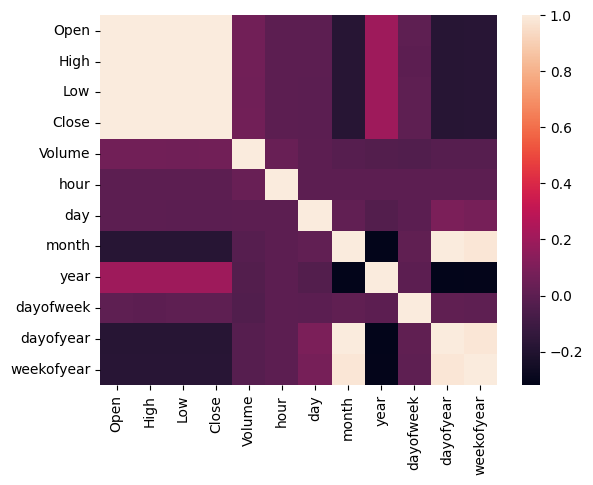

In [15]:
# correlation
sns.heatmap(df.corr())

In [16]:
# generating windows
# 24 hour window to predict 25th hour using only close

close = df.iloc[:,3]
windows = []
target = []
length = 24

for i in range(len(close)-length):
    x = close.iloc[i:i+length]
    y = close.iloc[i+length]

    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target).reshape(-1,1)

In [17]:
# creating train and test data

from sklearn.preprocessing import MinMaxScaler

In [18]:
sc = MinMaxScaler()

windows_sc = sc.fit_transform(windows)
target_sc = sc.fit_transform(target)

windows_sc = windows_sc.reshape((len(windows_sc),length,1))

In [19]:
# splitting

split = int(0.8*len(windows_sc))

X_train = windows_sc[:split,:,:]
X_test = windows_sc[split:,:,:]

y_train = target_sc[:split,:]
y_test = target_sc[split:,:]

In [20]:
print(X_train.shape,y_train.shape)

(27578, 24, 1) (27578, 1)


<Axes: xlabel='Date', ylabel='Close'>

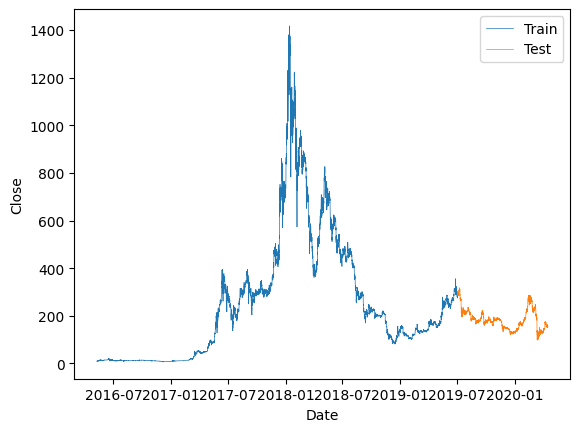

In [21]:
# plotting training and testing data

sns.lineplot(data=df['Close'][:split],label='Train',linewidth=0.5)
sns.lineplot(data=df['Close'][split:],label='Test',linewidth=0.5)

In [22]:
# Model building and training

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras import *

In [25]:
model = Sequential()

model.add(LSTM(100,input_shape=(X_train.shape[1],X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Dense(1,activation='linear')),
model.compile(optimizer='adam',loss='mse')



In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.fit(X_train,y_train, epochs=5, batch_size=100, verbose=1)

Epoch 1/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - loss: 0.0020
Epoch 2/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 2.9570e-04
Epoch 3/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 2.4684e-04
Epoch 4/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 2.1950e-04
Epoch 5/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 2.2257e-04


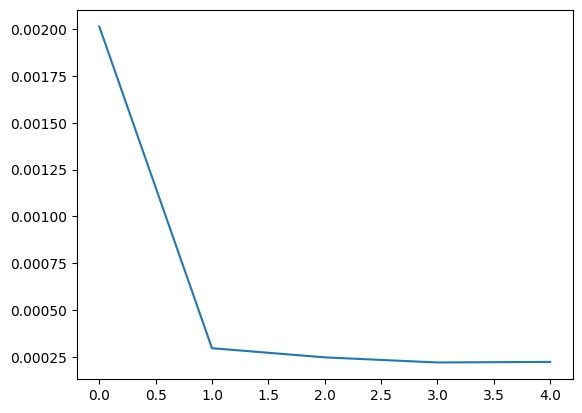

In [28]:
plt.plot(model.history.history['loss'])

In [29]:
pred_sc= model.predict(X_test)
pred= sc.inverse_transform(pred_sc)
y_test_ic=sc.inverse_transform(y_test)

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


The coefficient of determination (R-squared) =0.927


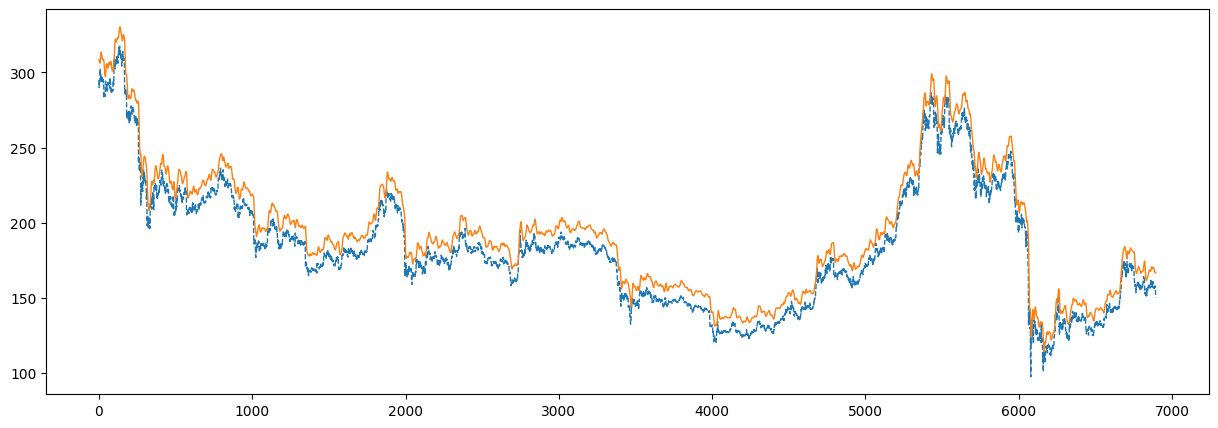

In [31]:
from sklearn.metrics import r2_score

print('The coefficient of determination (R-squared) ={:.3f}'.format(r2_score(pred,y_test_ic)))

plt.figure(figsize=(15,5))
plt.plot(y_test_ic,'--',label='Actual',linewidth=1)
plt.plot(pred,label='Predicted',linewidth=1)

In [32]:
# model building

model = Sequential()

model.add(LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# training on entire dataset

X = windows_sc
y = target_sc

history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=100,
    verbose=1
)

Epoch 1/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 0.0011
Epoch 2/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 2.0857e-04
Epoch 3/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - loss: 1.8663e-04
Epoch 4/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 1.6861e-04
Epoch 5/5
345/345 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 1.5449e-04


In [35]:
!pip install tqdm
from datetime import datetime
from tqdm import tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)


In [36]:
# future dates

str_d1 = '2020/04/16'
str_d2 = '2020/04/30'

# convert string to datetime object
d1 = datetime.strptime(str_d1, "%Y/%m/%d")
d2 = datetime.strptime(str_d2, "%Y/%m/%d")

delta = d2 - d1

steps_in_future = delta.days * 24

print("Steps in future:", steps_in_future)

Steps in future: 336


In [37]:
# iterative prediction of each future step

f_wind = windows_sc[-1]
f_tar = target_sc[-1]

new = []

for i in tqdm(range(steps_in_future)):

    curr = np.append(f_wind[1:], [f_tar]).reshape(-1,1)

    next_pred = model.predict(curr.reshape(1, length, 1), verbose=0)

    pred_ic = sc.inverse_transform(next_pred)

    new.append(pred_ic[0][0])

    f_wind = curr
    f_tar = next_pred

100%|████████████████████████████████████████████████████████████████████████████████| 336/336 [00:47<00:00,  7.13it/s]


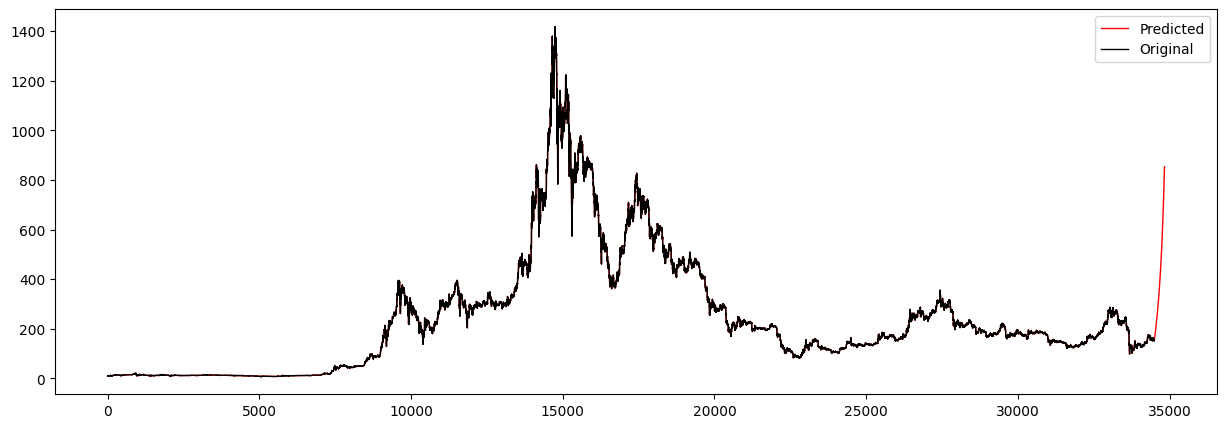

In [38]:
# plotting future predictions

out = np.append(df.Close.values, new)

plt.figure(figsize=(15,5))

plt.plot(out, linewidth=1, color='red', label='Predicted')
plt.plot(df.Close.values, linewidth=1, color='black', label='Original')

plt.legend()
plt.show()

In [41]:
len(out), len(df.Close)

(34833, 34497)

In [45]:
#saving model
import pickle
model.save('model.h5')
filename='scaler.pkl'
f= open(filename,'wb')
pickle.dump(sc,f )
f.close()

In [46]:
with open('window.npy', 'wb') as f:
    np.save(f, windows_sc)
with open('target_npy','wb') as f:
    np.save(f,target_sc)